In [6]:
# Basic Modules
import pandas as pd
import numpy as np
import scipy as stats
from scipy.stats import skew

In [7]:
# Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load cleaned data files into pandas DataFrames
# 'ISO-8859-1' encoding is used for building_descriptions_df to handle special characters
# that would cause issues with the default 'utf-8' encoding

yearly_values_df = pd.read_csv("C:/Users/barre/Alexandria Personal Project/Cleaned Data/cleaned_yearly_values.csv")
sales_data_df = pd.read_csv("C:/Users/barre/Alexandria Personal Project/Cleaned Data/cleaned_sales_data.csv")
building_descriptions_df = pd.read_csv("C:/Users/barre/Alexandria Personal Project/Cleaned Data/cleaned_building_descriptions.csv", encoding='ISO-8859-1')

In [9]:
yearly_values_df = yearly_values_df.rename(columns={'levy_year':'year'})
yearly_values_df = yearly_values_df.drop_duplicates(subset=['account_num', 'year'])
print("Levy duplicates:", yearly_values_df.duplicated(subset=['account_num', 'year']).sum())
yearly_values_df.head()

Levy duplicates: 0


,account_num,land_value,building_value,total_value,zip_code,levy_month,year
0,50467480,103179,233965,337144,22302,1,2024
1,50467480,96328,195787,292115,22302,1,2023
2,50467480,91741,186464,278205,22302,1,2022
3,50467480,91741,186464,278205,22302,1,2021
4,50467480,79775,162142,241917,22302,1,2020


In [10]:
yearly_values_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784434 entries, 0 to 1622001
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   account_num     784434 non-null  int64
 1   land_value      784434 non-null  int64
 2   building_value  784434 non-null  int64
 3   total_value     784434 non-null  int64
 4   zip_code        784434 non-null  int64
 5   levy_month      784434 non-null  int64
 6   year            784434 non-null  int64
dtypes: int64(7)
memory usage: 47.9 MB


In [11]:
print("Missing values in yearly_values_df (by column):")
print(yearly_values_df.isnull().sum())

Missing values in yearly_values_df (by column):
account_num       0
land_value        0
building_value    0
total_value       0
zip_code          0
levy_month        0
year              0
dtype: int64


In [12]:
sales_data_df = sales_data_df.rename(columns={'num':'account_num', 'sale_years':'year'})
sales_data_df = sales_data_df.drop_duplicates(subset=['account_num', 'year'])
print("Sales data duplicates:", sales_data_df.duplicated(subset=['account_num', 'year']).sum())
sales_data_df.head()

Sales data duplicates: 0


,account_num,sale_price,sale_month,sale_day,year
0,15890000,1200000,7,23,2009
1,15890000,289000,7,30,1999
2,15890000,259000,10,25,1994
3,15890000,114900,3,22,1985
4,11497500,2050000,10,17,2018


In [13]:
sales_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110507 entries, 0 to 117125
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   account_num  110507 non-null  int64
 1   sale_price   110507 non-null  int64
 2   sale_month   110507 non-null  int64
 3   sale_day     110507 non-null  int64
 4   year         110507 non-null  int64
dtypes: int64(5)
memory usage: 5.1 MB


In [14]:
print("Missing values in sales_data_df (by column):")
print(sales_data_df.isnull().sum())

Missing values in sales_data_df (by column):
account_num    0
sale_price     0
sale_month     0
sale_day       0
year           0
dtype: int64


In [15]:
building_descriptions_df.head()

,account_num,year_built,construction_quality,building_condition,hvac,building_type,gross_building_area,net_leasable_area
0,50466800,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,NaN,NaN
1,50466810,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,NaN,NaN
2,50466820,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,NaN,NaN
3,50466830,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,NaN,NaN
4,50466840,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,NaN,NaN


In [16]:
building_descriptions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17728 entries, 0 to 17727
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   account_num           17728 non-null  int64 
 1   year_built            17728 non-null  int64 
 2   construction_quality  17728 non-null  object
 3   building_condition    17728 non-null  object
 4   hvac                  17728 non-null  object
 5   building_type         17728 non-null  object
 6   gross_building_area   2451 non-null   object
 7   net_leasable_area     2451 non-null   object
dtypes: int64(2), object(6)
memory usage: 1.1+ MB


In [17]:
print("Missing values in building_descriptions_df (by column):")
print(building_descriptions_df.isnull().sum())

Missing values in building_descriptions_df (by column):
account_num                 0
year_built                  0
construction_quality        0
building_condition          0
hvac                        0
building_type               0
gross_building_area     15277
net_leasable_area       15277
dtype: int64


In [18]:
building_descriptions_df.drop(columns=['gross_building_area', 'net_leasable_area'], inplace=True)
building_descriptions_df.head()

,account_num,year_built,construction_quality,building_condition,hvac,building_type
0,50466800,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES
1,50466810,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES
2,50466820,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES
3,50466830,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES
4,50466840,1961,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES


In [19]:
# Step 1: Get the most recent building description for each property
building_descriptions = building_descriptions_df.sort_values('year_built').groupby('account_num').last().reset_index()

# Step 2: Create all possible property-year combinations
all_years = pd.concat([
    yearly_values_df[['account_num', 'year']],
    sales_data_df[['account_num', 'year']]
]).drop_duplicates()

# Step 3: Merge building descriptions FIRST (before year filtering)
master_df = all_years.merge(building_descriptions, on='account_num', how='left')

# Step 4: Only nullify building info for years BEFORE construction
has_building_info = ~master_df['year_built'].isna()
mask = (master_df['year'] < master_df['year_built']) & has_building_info
building_cols = ['year_built', 'construction_quality', 'building_condition', 'hvac', 'building_type']
master_df.loc[mask, building_cols] = np.nan


In [20]:
# Step 5: Now merge with assessment and sales data
master_df = master_df.merge(
    yearly_values_df,
    on=['account_num', 'year'],
    how='left'
)

master_df = master_df.merge(
    sales_data_df,
    on=['account_num', 'year'],
    how='left'
)

# Final cleanup
master_df = master_df.sort_values(['account_num', 'year'])

In [21]:
master_df[master_df['account_num'] == 50466800]

,account_num,year,year_built,construction_quality,building_condition,hvac,building_type,land_value,building_value,total_value,zip_code,levy_month,sale_price,sale_month,sale_day
781200,50466800,2001,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,109529.0,248721.0,358250.0,22302.0,1.0,51000.0,11.0,1.0
783665,50466800,2002,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,17700.0,48500.0,66200.0,22302.0,1.0,NaN,NaN,NaN
783664,50466800,2003,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,29300.0,52800.0,82100.0,22302.0,1.0,NaN,NaN,NaN
783663,50466800,2004,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,38100.0,78000.0,116100.0,22302.0,1.0,NaN,NaN,NaN
783662,50466800,2005,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,47600.0,137700.0,185300.0,22302.0,1.0,NaN,NaN,NaN
783661,50466800,2006,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,69000.0,183200.0,252200.0,22302.0,1.0,NaN,NaN,NaN
783660,50466800,2007,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,69380.0,184208.0,253588.0,22302.0,1.0,NaN,NaN,NaN
783659,50466800,2008,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,69380.0,167629.0,237009.0,22302.0,1.0,NaN,NaN,NaN
783658,50466800,2009,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,69380.0,144141.0,213521.0,22302.0,1.0,177000.0,6.0,29.0
783657,50466800,2010,1961.0,GOOD,GOOD,CENTRAL AIR TO AIR,CONDO > 3 STORIES,58973.0,121078.0,180051.0,22302.0,1.0,NaN,NaN,NaN


In [22]:
master_df

,account_num,year,year_built,construction_quality,building_condition,hvac,building_type,land_value,building_value,total_value,zip_code,levy_month,sale_price,sale_month,sale_day
322598,10006030,2001,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,22314.0,1.0,NaN,NaN,NaN
322597,10006030,2002,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,22314.0,1.0,NaN,NaN,NaN
322596,10006030,2003,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,22314.0,1.0,NaN,NaN,NaN
322595,10006030,2004,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,22314.0,1.0,NaN,NaN,NaN
322594,10006030,2005,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,22314.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820341,60050110,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40139528.0,2.0,26.0
820344,60050120,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40053000.0,12.0,30.0
820343,60050120,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40139528.0,2.0,26.0
782028,60050130,2001,NaN,NaN,NaN,NaN,NaN,781264.0,1013559.0,1794823.0,22305.0,1.0,NaN,NaN,NaN


In [23]:
master_df.isna().any()  

account_num             False
year                    False
year_built               True
construction_quality     True
building_condition       True
hvac                     True
building_type            True
land_value               True
building_value           True
total_value              True
zip_code                 True
levy_month               True
sale_price               True
sale_month               True
sale_day                 True
dtype: bool

In [24]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   account_num           839723 non-null  int64  
 1   year                  839723 non-null  int64  
 2   year_built            345146 non-null  float64
 3   construction_quality  345146 non-null  object 
 4   building_condition    345146 non-null  object 
 5   hvac                  345146 non-null  object 
 6   building_type         345146 non-null  object 
 7   land_value            784434 non-null  float64
 8   building_value        784434 non-null  float64
 9   total_value           784434 non-null  float64
 10  zip_code              784434 non-null  float64
 11  levy_month            784434 non-null  float64
 12  sale_price            110507 non-null  float64
 13  sale_month            110507 non-null  float64
 14  sale_day              110507 non-null  float64
dtype

In [25]:
cat_df = master_df[['year','account_num', 'construction_quality', 'building_condition', 'hvac', 'building_type']]
cat_df[cat_df.notna().all(axis=1)].head()

,year,account_num,construction_quality,building_condition,hvac,building_type
798828,1986,10012650,GOOD,GOOD,COMPLETE HVAC,MAIL PROCESSING FACILITY
798827,1996,10012650,GOOD,GOOD,COMPLETE HVAC,MAIL PROCESSING FACILITY
797111,1981,10040600,GOOD,GOOD,WARM AND COOL AIR ZONE,OFFICE BUILDING
162325,2001,10040600,GOOD,GOOD,WARM AND COOL AIR ZONE,OFFICE BUILDING
162324,2002,10040600,GOOD,GOOD,WARM AND COOL AIR ZONE,OFFICE BUILDING


In [26]:
num_df = master_df.select_dtypes(include='number')
num_df[num_df.notna().all(axis=1)].head()

,account_num,year,year_built,land_value,building_value,total_value,zip_code,levy_month,sale_price,sale_month,sale_day
162322,10040600,2004,1981.0,920100.0,2648600.0,3568700.0,22314.0,1.0,3895000.0,9.0,10.0
188816,10045500,2015,1950.0,2500000.0,1000.0,2501000.0,22301.0,1.0,5000000.0,6.0,9.0
378473,10088500,2007,1939.0,680400.0,655410.0,1335810.0,22311.0,1.0,2100000.0,9.0,6.0
378459,10088500,2021,1939.0,1049687.0,308280.0,1357967.0,22311.0,1.0,2400000.0,4.0,28.0
377677,10228000,2015,1900.0,478893.0,648118.0,1127011.0,22314.0,1.0,1075000.0,8.0,5.0


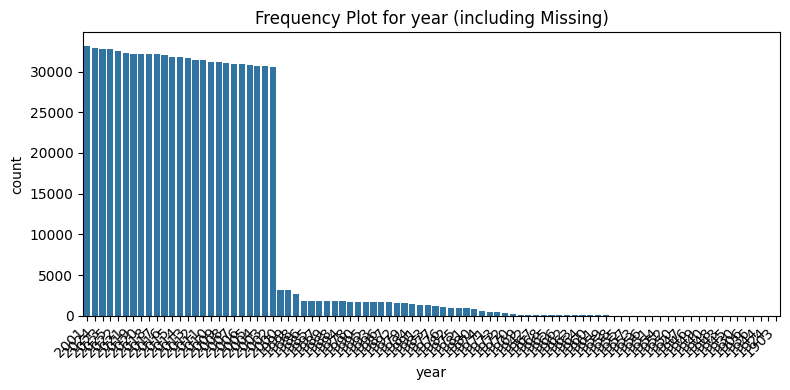

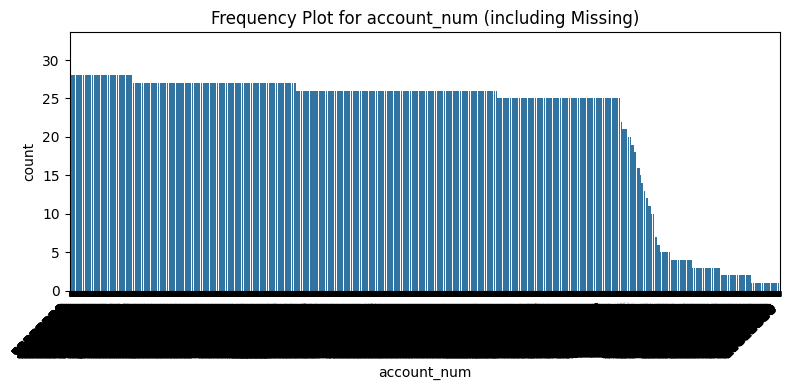

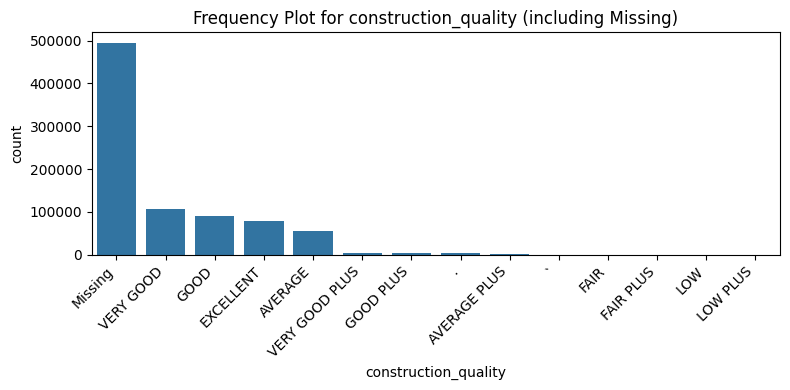

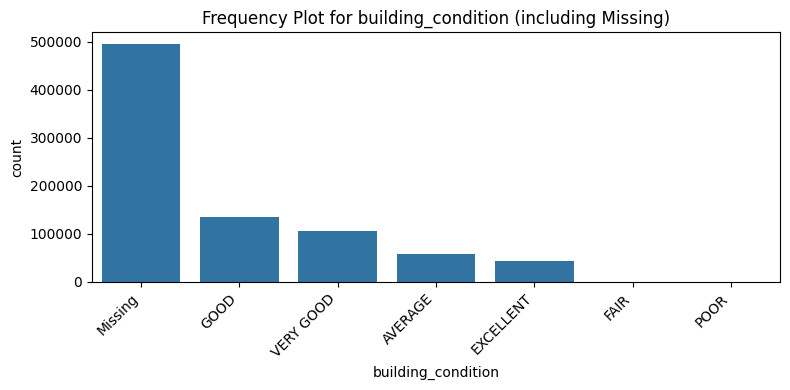

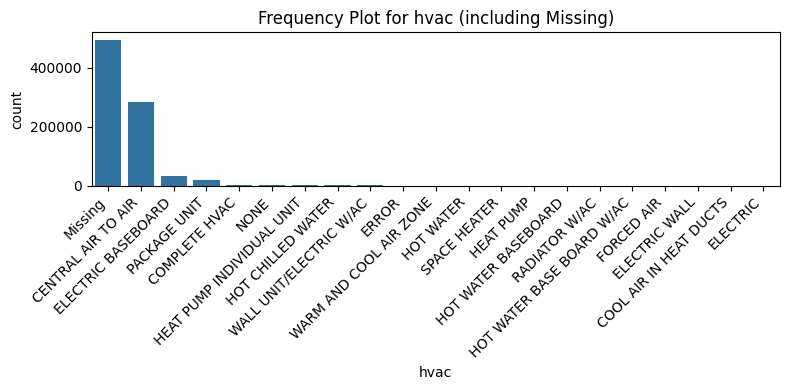

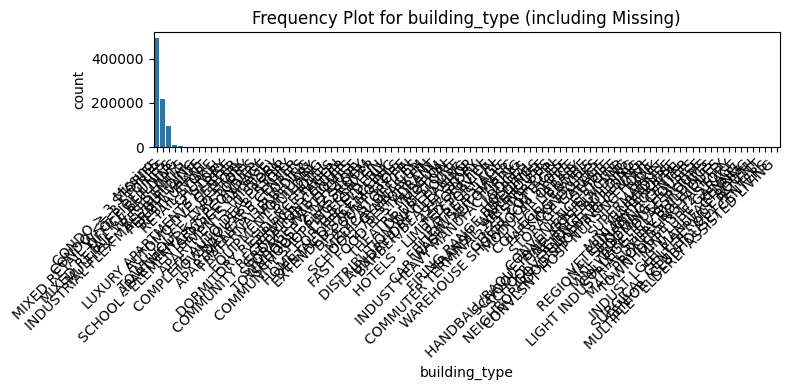

In [27]:
# Using seaborn countplot to visualize categorical frequency distributions
cat_df_with_nan = cat_df.fillna("Missing")

for col in cat_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cat_df_with_nan, x=col, order=cat_df_with_nan[col].value_counts().index)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Frequency Plot for {col} (including Missing)")
    plt.tight_layout()
    plt.show()

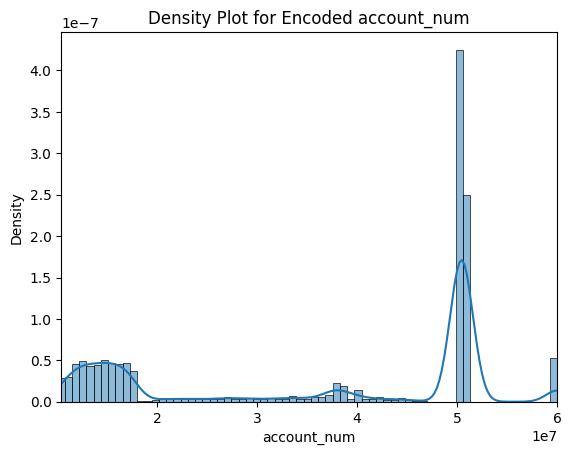

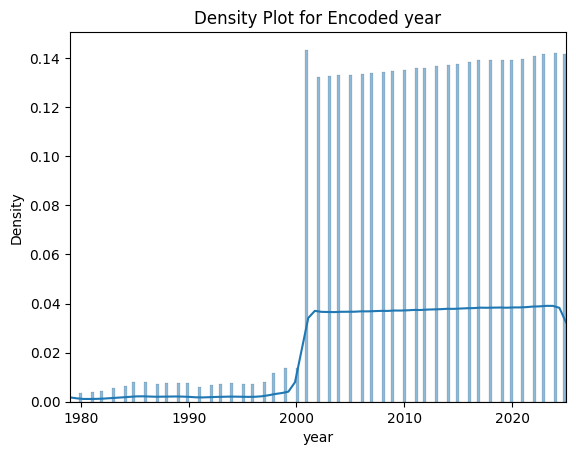

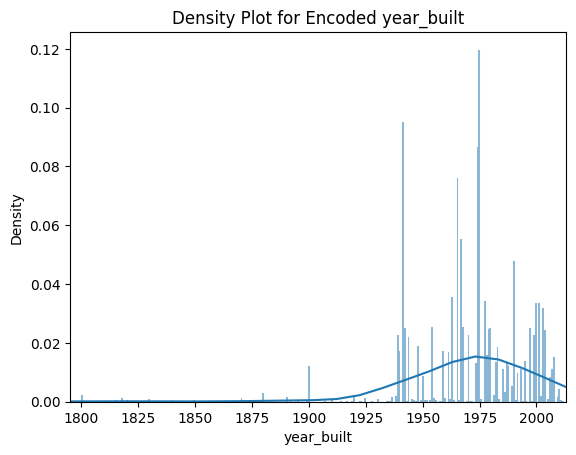

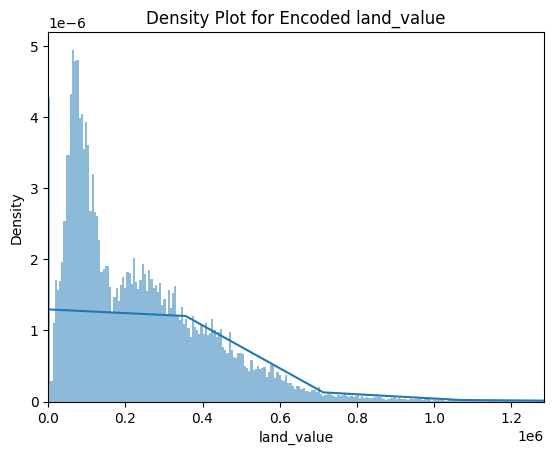

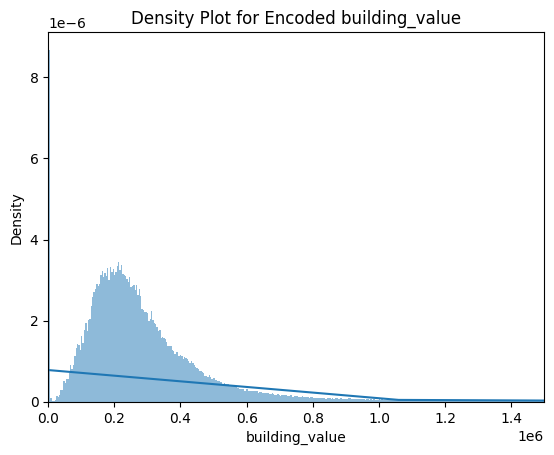

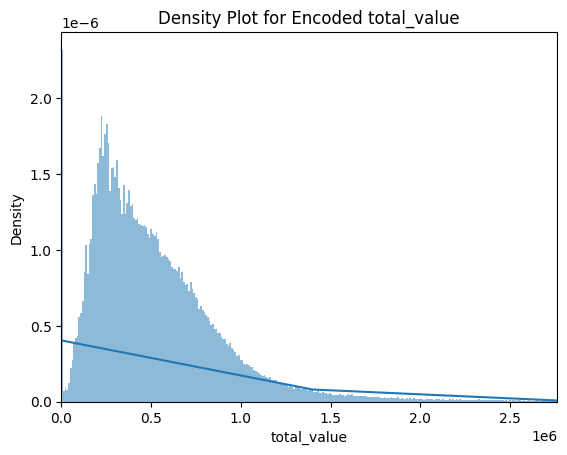

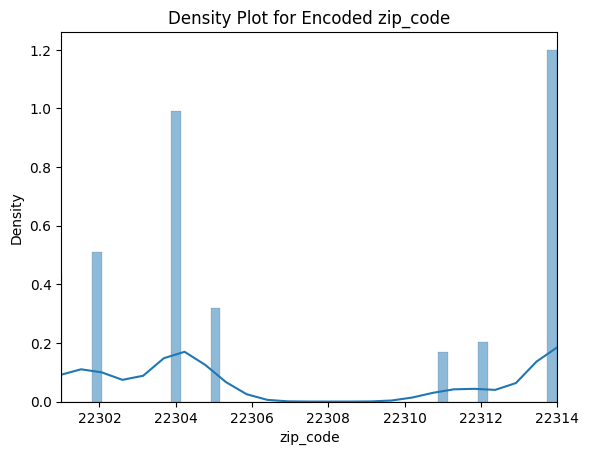

C:\Users\barre\AppData\Local\Temp\ipykernel_191648\1185474448.py:10: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(low, high)


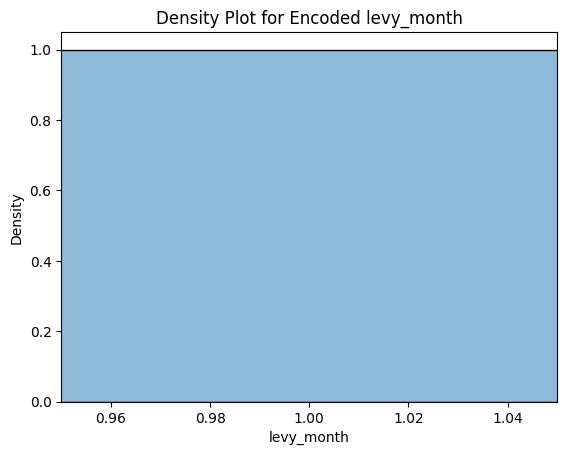

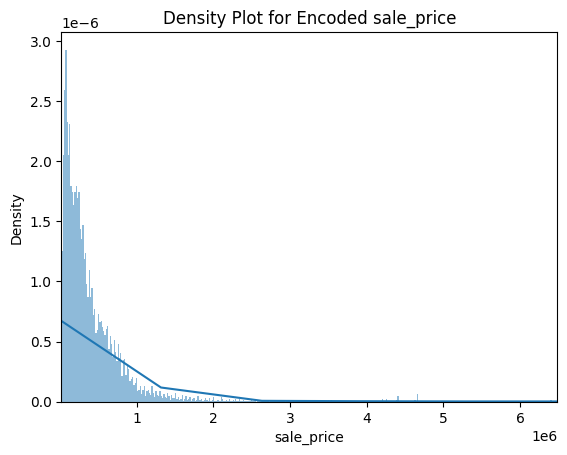

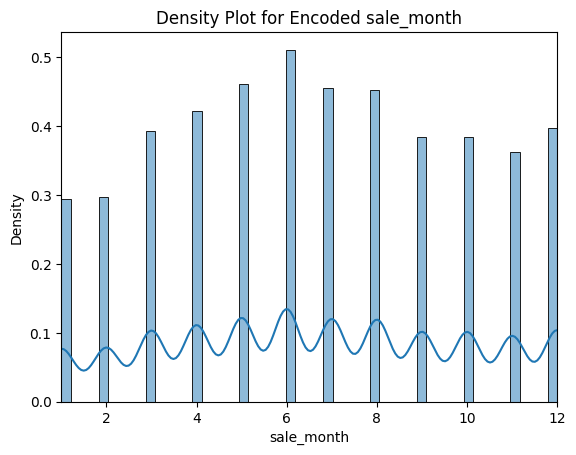

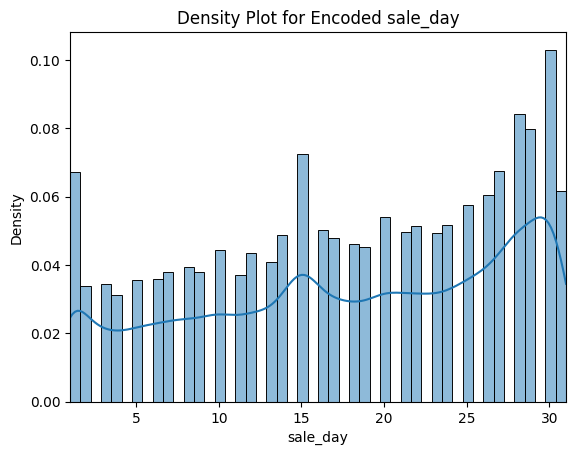

In [28]:
# Using seaborn countplot to visualize categorical frequency distributions
for col in num_df.columns:
    plt.figure()

    # Drop NaNs and get 1st and 99th percentiles
    series = num_df[col].dropna()
    low, high = series.quantile(0.01), series.quantile(0.99)

    sns.histplot(series, kde=True, stat='density')
    plt.xlim(low, high)
    plt.title(f"Density Plot for Encoded {col}")
    plt.show()

In [29]:
print("Skewness values:")
for col in num_df.columns:
    col_skew = skew(num_df[col].dropna())
    print(f"{col}: {col_skew:.2f}")

Skewness values:
account_num: -0.39
year: -1.12
year_built: -10.55
land_value: 37.18
building_value: 77.39
total_value: 64.78
zip_code: -7.15
levy_month: nan
sale_price: 29.62
sale_month: -0.00
sale_day: -0.29


C:\Users\barre\AppData\Local\Temp\ipykernel_191648\2095181061.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  col_skew = skew(num_df[col].dropna())


In [30]:
num_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   account_num     839723 non-null  int64  
 1   year            839723 non-null  int64  
 2   year_built      345146 non-null  float64
 3   land_value      784434 non-null  float64
 4   building_value  784434 non-null  float64
 5   total_value     784434 non-null  float64
 6   zip_code        784434 non-null  float64
 7   levy_month      784434 non-null  float64
 8   sale_price      110507 non-null  float64
 9   sale_month      110507 non-null  float64
 10  sale_day        110507 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 76.9 MB


In [31]:
# 1. Calculate building_age (will be NaN if year_built is missing)
num_df['building_age'] = num_df['year'] - num_df['year_built']

# 2. Flag sales (1 if sale occurred, 0 otherwise)
num_df['had_sale'] = num_df['sale_price'].notna().astype(int)

# 3. Fill sale-related columns with 0 where no sale occurred
sale_cols = ['sale_price', 'sale_month', 'sale_day']
num_df[sale_cols] = num_df[sale_cols].fillna(0)

# 3.5 Define function to compute last sale year and price before each year for each property
def compute_last_sales(group):
    # Sort the data for this property chronologically
    group = group.sort_values('year')

    last_years = []
    last_prices = []

    # Loop through each row in the group
    for _, row in group.iterrows():
        # Filter past sales with sale_price > 0 before current year
        past_sales = group[(group['sale_price'] > 0) & (group['year'] < row['year'])]

        if not past_sales.empty:
            last_sale = past_sales.iloc[-1]  # most recent past sale
            last_years.append(last_sale['year'])
            last_prices.append(last_sale['sale_price'])
        else:
            last_years.append(float('nan'))
            last_prices.append(float('nan'))

    # Add results as new columns
    group['last_sale_year'] = last_years
    group['last_sale_price'] = last_prices

    return group

# Apply the function by property
num_df = num_df.groupby('account_num', group_keys=False).apply(compute_last_sales)

# 4. Forward-fill value columns to carry assessments forward
num_df = num_df.sort_values(['account_num', 'year'])
value_cols = ['land_value', 'building_value', 'total_value', 'zip_code', 'levy_month']
num_df[value_cols] = num_df.groupby('account_num')[value_cols].ffill()

# 5. Remove rows with both land_value and building_value missing or zero, unless a sale occurred
condition = (
    num_df[['land_value', 'building_value']].fillna(0).eq(0).all(axis=1) & 
    (num_df['had_sale'] == 0)
)
num_df = num_df[~condition]

# 6. Forward-fill 'last_sale_year' within each property (if needed)
num_df['last_sale_year'] = num_df.groupby('account_num')['last_sale_year'].ffill()

# 7. Calculate years since last sale (NaN if no sale ever occurred)
num_df['years_since_last_sale'] = num_df['year'] - num_df['last_sale_year']

# 8. Create target variable: next year's total_value for each property
num_df['target_total_value'] = num_df.groupby('account_num')['total_value'].shift(-1)


C:\Users\barre\AppData\Local\Temp\ipykernel_191648\607158447.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num_df = num_df.groupby('account_num', group_keys=False).apply(compute_last_sales)


In [32]:
num_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824070 entries, 324306 to 263083
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   account_num            824070 non-null  int64  
 1   year                   824070 non-null  int64  
 2   year_built             339880 non-null  float64
 3   land_value             769188 non-null  float64
 4   building_value         769188 non-null  float64
 5   total_value            769188 non-null  float64
 6   zip_code               769188 non-null  float64
 7   levy_month             769188 non-null  float64
 8   sale_price             824070 non-null  float64
 9   sale_month             824070 non-null  float64
 10  sale_day               824070 non-null  float64
 11  building_age           339880 non-null  float64
 12  had_sale               824070 non-null  int64  
 13  last_sale_year         739754 non-null  float64
 14  last_sale_price        739754 non-nu

In [33]:
num_df_copy = num_df[~num_df['total_value'].isna()].copy()

In [34]:
num_df_copy[num_df_copy['account_num'] == 10040600]

,account_num,year,year_built,land_value,building_value,total_value,zip_code,levy_month,sale_price,sale_month,sale_day,building_age,had_sale,last_sale_year,last_sale_price,years_since_last_sale,target_total_value
162325,10040600,2001,1981.0,723300.0,2249900.0,2973200.0,22314.0,1.0,0.0,0.0,0.0,20.0,0,1981.0,365241.0,20.0,3038700.0
162324,10040600,2002,1981.0,723300.0,2315400.0,3038700.0,22314.0,1.0,0.0,0.0,0.0,21.0,0,1981.0,365241.0,21.0,3038700.0
162323,10040600,2003,1981.0,795600.0,2243100.0,3038700.0,22314.0,1.0,0.0,0.0,0.0,22.0,0,1981.0,365241.0,22.0,3568700.0
162322,10040600,2004,1981.0,920100.0,2648600.0,3568700.0,22314.0,1.0,3895000.0,9.0,10.0,23.0,1,1981.0,365241.0,23.0,3988600.0
162321,10040600,2005,1981.0,1104100.0,2884500.0,3988600.0,22314.0,1.0,0.0,0.0,0.0,24.0,0,2004.0,3895000.0,1.0,4461500.0
162320,10040600,2006,1981.0,1269700.0,3191800.0,4461500.0,22314.0,1.0,0.0,0.0,0.0,25.0,0,2004.0,3895000.0,2.0,5244700.0
162319,10040600,2007,1981.0,1269700.0,3975000.0,5244700.0,22314.0,1.0,0.0,0.0,0.0,26.0,0,2004.0,3895000.0,3.0,5359200.0
162318,10040600,2008,1981.0,1396670.0,3962530.0,5359200.0,22314.0,1.0,0.0,0.0,0.0,27.0,0,2004.0,3895000.0,4.0,5359200.0
162317,10040600,2009,1981.0,1396670.0,3962530.0,5359200.0,22314.0,1.0,0.0,0.0,0.0,28.0,0,2004.0,3895000.0,5.0,4685100.0
162316,10040600,2010,1981.0,1220992.0,3464108.0,4685100.0,22314.0,1.0,0.0,0.0,0.0,29.0,0,2004.0,3895000.0,6.0,5151400.0


In [35]:
num_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769188 entries, 324306 to 263083
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   account_num            769188 non-null  int64  
 1   year                   769188 non-null  int64  
 2   year_built             315090 non-null  float64
 3   land_value             769188 non-null  float64
 4   building_value         769188 non-null  float64
 5   total_value            769188 non-null  float64
 6   zip_code               769188 non-null  float64
 7   levy_month             769188 non-null  float64
 8   sale_price             769188 non-null  float64
 9   sale_month             769188 non-null  float64
 10  sale_day               769188 non-null  float64
 11  building_age           315090 non-null  float64
 12  had_sale               769188 non-null  int64  
 13  last_sale_year         714349 non-null  float64
 14  last_sale_price        714349 non-nu

In [36]:
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   year                  839723 non-null  int64 
 1   account_num           839723 non-null  int64 
 2   construction_quality  345146 non-null  object
 3   building_condition    345146 non-null  object
 4   hvac                  345146 non-null  object
 5   building_type         345146 non-null  object
dtypes: int64(2), object(4)
memory usage: 44.8+ MB


In [37]:
for col in cat_df.columns:
    print(f"Unique values in {col}:")
    print(cat_df[col].unique())
    print()

Unique values in year:
[2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 1986 1996 1977
 1981 1983 1980 1994 1998 1978 1974 1989 1987 1982 1988 2000 1968 1992
 1972 1966 1976 1985 1999 1991 1993 1942 1975 1955 1984 1995 1990 1997
 1979 1973 1970 1959 1965 1948 1971 1954 1953 1964 1956 1963 1969 1961
 1962 1930 1960 1967 1950 1943 1947 1906 1957 1936 1949 1958 1945 1952
 1946 1951 1944 1940 1924 1903]

Unique values in account_num:
[10006030 10009500 10012650 ... 60050110 60050120 60050130]

Unique values in construction_quality:
[nan 'GOOD' 'GOOD PLUS' 'AVERAGE PLUS' 'VERY GOOD' 'AVERAGE'
 'VERY GOOD PLUS' 'EXCELLENT' 'FAIR PLUS' 'LOW PLUS' 'FAIR' '.' 'LOW' '`']

Unique values in building_condition:
[nan 'GOOD' 'POOR' 'AVERAGE' 'FAIR' 'VERY GOOD' 'EXCELLENT']

Unique values in hvac:
[nan 'COMPLETE HVAC' 'WARM AND COOL AIR ZONE' 'PACKAGE UNIT'
 'HOT CHILLED WATER' 'HEAT PUMP INDIVIDUAL UNIT'
 'HOT WATER BASE BO

In [38]:
cat_df_copy = cat_df.copy()

In [39]:
# Categorical Featuere Engineering & Encoding
# Convert categorical features to one-hot encoding
quality_order = {
    'LOW': 1, 'LOW PLUS': 2,
    'FAIR': 3, 'FAIR PLUS': 4,
    'AVERAGE': 5, 'AVERAGE PLUS': 6,
    'GOOD': 7, 'GOOD PLUS': 8,
    'VERY GOOD': 9, 'VERY GOOD PLUS': 10,
    'EXCELLENT': 11,
    'MISSING': 0
}

cat_df_copy['construction_quality'] = cat_df_copy['construction_quality'].replace({'.': np.nan, '`': np.nan})
cat_df_copy['construction_quality'] = cat_df_copy['construction_quality'].fillna('MISSING')

cat_df_copy['construction_quality_numeric'] = cat_df_copy['construction_quality'].replace({'.': np.nan, '`': np.nan})
cat_df_copy['construction_quality_numeric'] = cat_df_copy['construction_quality_numeric'].fillna('MISSING')
cat_df_copy['construction_quality_numeric'] = cat_df_copy['construction_quality_numeric'].map(quality_order).astype(int)

In [40]:
# 'GOOD' 'POOR' 'AVERAGE' 'FAIR' 'VERY GOOD' 'EXCELLENT'
condition_order = {
    'GOOD': 1, 'POOR': 2, 'AVERAGE': 3,
    'FAIR': 4, 'VERY GOOD': 5, 'EXCELLENT': 6,
    'MISSING': 0
}

cat_df_copy['building_condition'] = cat_df_copy['building_condition'].fillna('MISSING')

cat_df_copy['building_condition_numeric'] = cat_df_copy['building_condition'].fillna('MISSING')
cat_df_copy['building_condition_numeric'] = cat_df_copy['building_condition_numeric'].map(condition_order).astype(int)

In [41]:
# To reduce the cardanlity of 'hvac', domain-informed feature engineering can be applied
'''
Unique values in hvac:
[nan 'COMPLETE HVAC' 'WARM AND COOL AIR ZONE' 'PACKAGE UNIT'
 'HOT CHILLED WATER' 'HEAT PUMP INDIVIDUAL UNIT'
 'HOT WATER BASE BOARD W/AC' 'HOT WATER' 'RADIATOR W/AC'
 'HOT WATER BASEBOARD' 'HEAT PUMP' 'SPACE HEATER' 'NONE'
 'CENTRAL AIR TO AIR' 'FORCED AIR' 'ELECTRIC WALL' 'ELECTRIC'
 'ELECTRIC BASEBOARD' 'WALL UNIT/ELECTRIC W/AC' 'ERROR'
 'COOL AIR IN HEAT DUCTS']
'''
hvac_map = {
    'HOT CHILLED WATER': 'HOT WATER',
    'HOT WATER BASE BOARD W/AC': 'HOT WATER',
    'HOT WATER BASEBOARD': 'HOT WATER',
    'HEAT PUMP INDIVIDUAL UNIT': 'HEAT PUMP', 
    'ELECTRIC BASEBOARD': 'ELECTRIC',
    'ELECTRIC WALL': 'ELECTRIC',
    'WALL UNIT/ELECTRIC W/AC': 'ELECTRIC',
    np.nan: 'UKNOWN', 
    'ERROR': 'UKNOWN',
}

cat_df_copy['hvac_grouped'] = cat_df_copy['hvac'].replace(hvac_map)


In [42]:
cat_df_copy['hvac_grouped'].unique()

array(['UKNOWN', 'COMPLETE HVAC', 'WARM AND COOL AIR ZONE',
       'PACKAGE UNIT', 'HOT WATER', 'HEAT PUMP', 'RADIATOR W/AC',
       'SPACE HEATER', 'NONE', 'CENTRAL AIR TO AIR', 'FORCED AIR',
       'ELECTRIC', 'COOL AIR IN HEAT DUCTS'], dtype=object)

In [43]:
# Since hvac types are not ordinal, we can use one-hot encoding


In [44]:
'''
Unique values in building_type:
[nan 'MAIL PROCESSING FACILITY' 'OFFICE BUILDING' 'RESTAURANT'
 'DISCOUNT STORE' 'MIXED RETAIL W/ OFFICE UNITS'
 'MIXED RETAIL W/ RES UNITS' 'VETERINARY HOSPITAL'
 'INDUST HEAVY MANUFACTURING' 'EXTENDED STAY MOTELS' 'RETAIL STORE'
 '3 STORY' 'MULTIPLE - RESIDENTIAL' 'INDUSTRIAL FLEX MALL BUILDING'
 '2½ STORY' '2 STORY' 'CONDO <= 3 STORIES' 'DENTAL OFFICE/ CLINIC'
 'SERVICE GARAGE' 'COMMUNITY RECREATION CENTER' 'DAY CARE CENTER'
 'SERVICE STATION' 'BARBER/BEAUTY SHOP' 'FAST FOOD RESTAURANT' 'CHURCH'
 'AUTOMOTIVE CENTER' 'APARTMENTS (HI-RISE)' 'APARTMENT > 3 STORIES'
 'MINI WAREHOUSE HI-RISE' 'CAR WASH - AUTOMATIC'
 'LUXURY APARTMENTS HI-RISE' 'MORTUARY' 'MEDICAL OFFICES' 'DRUG STORE'
 '2.25 STORY FIN' 'HOTEL' 'LUXURY BOUTIQUES' 'FELLOWSHIP HALLS'
 'SCHOOL - CLASSROOM' 'LODGES' 'THEATRE - MOTION' 'PERMIT VALUE' 'LIBRARY'
 'CONVENIENCE STORE' 'GROUP CARE HOMES' 'BANK' 'GUEST COTTAGES'
 'SCHOOL - ELEMENTARY/SECONDARY' 'THEATRE - STAGE' '1½ STORY FIN'
 'CONDO > 3 STORIES' 'SUPERMARKET' '3.25 STORY FIN' 'FRATERNAL BUILDING'
 '3.5 STORY FIN' 'STORAGE WAREHOUSE' 'MINI WAREHOUSE' 'SELF SERVICE BOOTH'
 '1 STORY' 'NEIGHBORHOOD SHOPPING CENTER' 'CONVLSNT HOSP NURSING HOME'
 'TOWNHOUSE TWO STORY' 'COMPLETE AUTO DEALERSHIP' 'MODULAR OFFICE'
 'LAUNDRY/DRY CLEANING' 'DISTRIBUTION WAREHOUSE'
 'WAREHOUSE SHOWROOM STORE' 'KENNEL' 'INDUST LGHT MANUFACTURING'
 'GOVERNMENT BUILDING' 'MINI LUBE GARAGE' 'STORAGE GARAGE' 'STABLE'
 'COMMUNITY SHOPPING CENTER' 'SENIOR (CLUBHOUSE) CENTERS'
 'TRANSIT WAREHOUSE' 'SURGICAL CENTER - OUT PATIENT'
 'HOME FOR THE ELDERLY' '2.75 STORY FIN' 'DORMITORY RESIDENCE HALLS'
 'COLLEGE - ENTIRE' 'SCHOOL - GYMNASIUM' 'HANDBALL/RAQUETBALL COURTS/CLUB'
 'SCHOOL - SCIENCE BUILDING' 'SCHOOL - FINE ARTS BUILDING'
 'APARTMENT <= 3 STORIES' 'HOTELS - LIMITED SERVICE' '4 STORY FIN'
 'COLLEGE - CLASSROOMS' 'MUSEUM' 'EQUIPMENT BUILDING'
 'COMMUTER TERMINAL, AIRLINE, BUS' 'PARKING LEVELS' 'TOWNHOUSE 3  STORY'
 'HOSPITAL' 'CONDO PKS' 'FIRING RANGE BUILDINGS' 'TOWNHOUSE 2 1/2 STORY'
 'TOWNHOUSE 3 1/2 STORY' 'CLUBHOUSE' 'MULTIPLE - ELDERLY ASSISTED LIVING'
 'ROOMING HOUSES' 'REGIONAL SHOPPING CENTER'
 'LIGHT INDUSTRIAL SHELL BUILDINGS']
 '''
# Grouping building types into broader categories to reduce cardinality
def simplify_building_type(x):
    if pd.isna(x): return 'Unknown'
    x = x.upper()
    if 'APARTMENT' in x or 'CONDO' in x or 'TOWNHOUSE' in x or 'RESIDENTIAL' in x or 'DORMITORY' in x:
        return 'Residential'
    elif 'RETAIL' in x or 'STORE' in x or 'RESTAURANT' in x or 'SHOPPING' in x or 'SUPERMARKET' in x or 'BOUTIQUE' in x:
        return 'Retail'
    elif 'OFFICE' in x or 'BANK' in x or 'GOVERNMENT' in x:
        return 'Office'
    elif 'WAREHOUSE' in x or 'INDUST' in x or 'STORAGE' in x:
        return 'Industrial'
    elif 'HOTEL' in x or 'MOTEL' in x or 'GUEST COTTAGE' in x:
        return 'Hospitality'
    elif 'SCHOOL' in x or 'COLLEGE' in x or 'CLASSROOM' in x:
        return 'Education'
    elif 'HOSP' in x or 'SURGICAL' in x or 'MEDICAL' in x or 'CLINIC' in x:
        return 'Healthcare'
    elif 'CHURCH' in x or 'HALL' in x or 'CLUB' in x or 'LIBRARY' in x or 'MUSEUM' in x:
        return 'Civic'
    elif 'AUTO' in x or 'GARAGE' in x or 'STATION' in x or 'CAR WASH' in x:
        return 'Auto'
    else:
        return 'Other'

cat_df_copy['building_type_grouped'] = cat_df_copy['building_type'].apply(simplify_building_type)

In [45]:
cat_df_copy['building_type_grouped'].unique()

array(['Unknown', 'Other', 'Office', 'Retail', 'Healthcare', 'Industrial',
       'Hospitality', 'Residential', 'Auto', 'Civic', 'Education'],
      dtype=object)

In [131]:
cat_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   year                          839723 non-null  int64 
 1   account_num                   839723 non-null  int64 
 2   construction_quality          839723 non-null  object
 3   building_condition            839723 non-null  object
 4   hvac                          345146 non-null  object
 5   building_type                 345146 non-null  object
 6   construction_quality_numeric  839723 non-null  int64 
 7   building_condition_numeric    839723 non-null  int64 
 8   hvac_grouped                  839723 non-null  object
 9   building_type_grouped         839723 non-null  object
dtypes: int64(4), object(6)
memory usage: 102.7+ MB


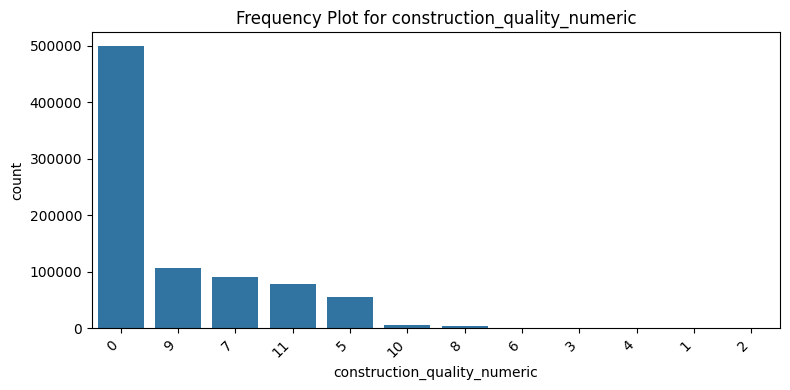

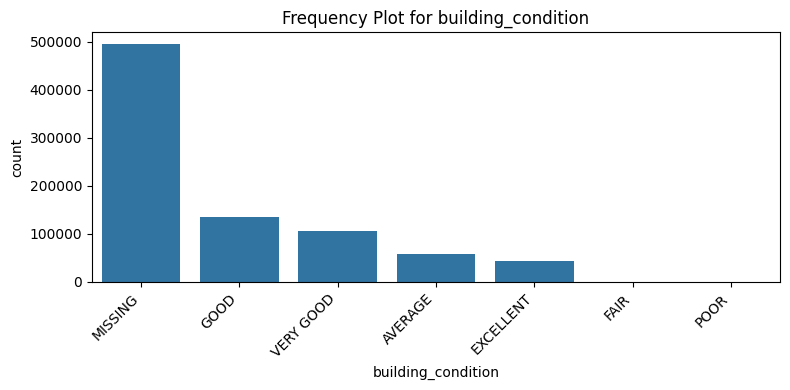

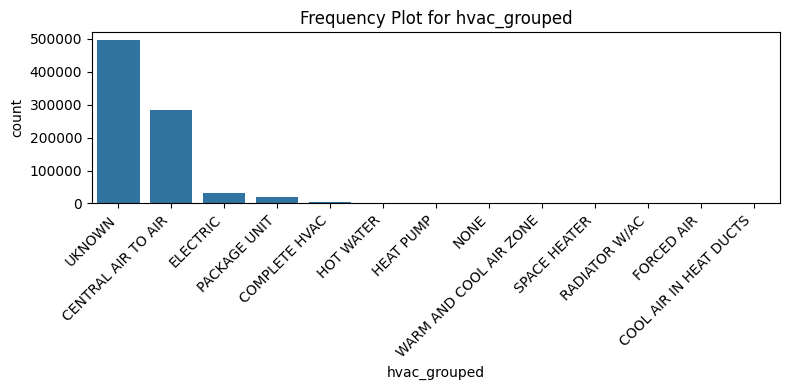

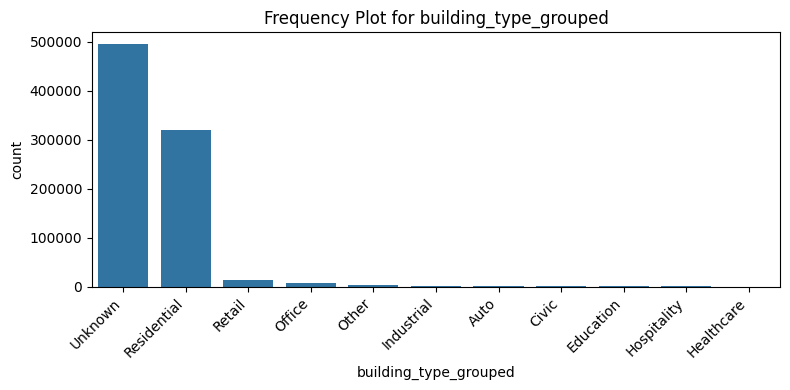

In [46]:
category_columns = ['construction_quality_numeric', 'building_condition', 'hvac_grouped', 'building_type_grouped']
for col in category_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cat_df_copy, x=col, order=cat_df_copy[col].value_counts().index)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Frequency Plot for {col}")
    plt.tight_layout()
    plt.show()

In [47]:
# While a lot of data is missing, we can try using it as a categorical feature and one-hot encoding it
hvac_dummies = pd.get_dummies(cat_df_copy['hvac_grouped'], prefix='hvac', drop_first=True)

# Drop original column and join dummies
cat_df_encoded = cat_df_copy.drop(columns=['hvac_grouped']).join(hvac_dummies)

It seems like for all of the categorical columns, the amount of missing data >60% may pose a severe inefficeincy for our model

In [48]:
cat_df_encoded.head()

,year,account_num,construction_quality,building_condition,hvac,building_type,construction_quality_numeric,building_condition_numeric,building_type_grouped,hvac_COMPLETE HVAC,...,hvac_ELECTRIC,hvac_FORCED AIR,hvac_HEAT PUMP,hvac_HOT WATER,hvac_NONE,hvac_PACKAGE UNIT,hvac_RADIATOR W/AC,hvac_SPACE HEATER,hvac_UKNOWN,hvac_WARM AND COOL AIR ZONE
322598,2001,10006030,MISSING,MISSING,NaN,NaN,0,0,Unknown,False,...,False,False,False,False,False,False,False,False,True,False
322597,2002,10006030,MISSING,MISSING,NaN,NaN,0,0,Unknown,False,...,False,False,False,False,False,False,False,False,True,False
322596,2003,10006030,MISSING,MISSING,NaN,NaN,0,0,Unknown,False,...,False,False,False,False,False,False,False,False,True,False
322595,2004,10006030,MISSING,MISSING,NaN,NaN,0,0,Unknown,False,...,False,False,False,False,False,False,False,False,True,False
322594,2005,10006030,MISSING,MISSING,NaN,NaN,0,0,Unknown,False,...,False,False,False,False,False,False,False,False,True,False


In [49]:
# While a lot of data is missing, we can try using it as a categorical feature and one-hot encoding it
building_type_dummies = pd.get_dummies(cat_df_encoded['building_type_grouped'], prefix='building_type', drop_first=True)

# Drop original column and join dummies
cat_df_encoded = cat_df_encoded.drop(columns=['building_type_grouped']).join(building_type_dummies)

In [50]:
cat_df_encoded.head()

,year,account_num,construction_quality,building_condition,hvac,building_type,construction_quality_numeric,building_condition_numeric,hvac_COMPLETE HVAC,hvac_COOL AIR IN HEAT DUCTS,...,building_type_Civic,building_type_Education,building_type_Healthcare,building_type_Hospitality,building_type_Industrial,building_type_Office,building_type_Other,building_type_Residential,building_type_Retail,building_type_Unknown
322598,2001,10006030,MISSING,MISSING,NaN,NaN,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
322597,2002,10006030,MISSING,MISSING,NaN,NaN,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
322596,2003,10006030,MISSING,MISSING,NaN,NaN,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
322595,2004,10006030,MISSING,MISSING,NaN,NaN,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
322594,2005,10006030,MISSING,MISSING,NaN,NaN,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True


In [51]:
cat_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   year                          839723 non-null  int64 
 1   account_num                   839723 non-null  int64 
 2   construction_quality          839723 non-null  object
 3   building_condition            839723 non-null  object
 4   hvac                          345146 non-null  object
 5   building_type                 345146 non-null  object
 6   construction_quality_numeric  839723 non-null  int64 
 7   building_condition_numeric    839723 non-null  int64 
 8   hvac_COMPLETE HVAC            839723 non-null  bool  
 9   hvac_COOL AIR IN HEAT DUCTS   839723 non-null  bool  
 10  hvac_ELECTRIC                 839723 non-null  bool  
 11  hvac_FORCED AIR               839723 non-null  bool  
 12  hvac_HEAT PUMP                839723 non-null  bool  
 13 

In [52]:
bool_cols = cat_df_encoded.select_dtypes(include='bool').columns
cat_df_encoded[bool_cols] = cat_df_encoded[bool_cols].astype('int8')

In [53]:
cat_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   year                          839723 non-null  int64 
 1   account_num                   839723 non-null  int64 
 2   construction_quality          839723 non-null  object
 3   building_condition            839723 non-null  object
 4   hvac                          345146 non-null  object
 5   building_type                 345146 non-null  object
 6   construction_quality_numeric  839723 non-null  int64 
 7   building_condition_numeric    839723 non-null  int64 
 8   hvac_COMPLETE HVAC            839723 non-null  int8  
 9   hvac_COOL AIR IN HEAT DUCTS   839723 non-null  int8  
 10  hvac_ELECTRIC                 839723 non-null  int8  
 11  hvac_FORCED AIR               839723 non-null  int8  
 12  hvac_HEAT PUMP                839723 non-null  int8  
 13 

In [54]:
cat_drop = ['construction_quality', 'building_condition', 'hvac', 'building_type']
cat_df_encoded = cat_df_encoded.drop(columns=cat_drop)

In [55]:
cat_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839723 entries, 322598 to 263083
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   year                          839723 non-null  int64
 1   account_num                   839723 non-null  int64
 2   construction_quality_numeric  839723 non-null  int64
 3   building_condition_numeric    839723 non-null  int64
 4   hvac_COMPLETE HVAC            839723 non-null  int8 
 5   hvac_COOL AIR IN HEAT DUCTS   839723 non-null  int8 
 6   hvac_ELECTRIC                 839723 non-null  int8 
 7   hvac_FORCED AIR               839723 non-null  int8 
 8   hvac_HEAT PUMP                839723 non-null  int8 
 9   hvac_HOT WATER                839723 non-null  int8 
 10  hvac_NONE                     839723 non-null  int8 
 11  hvac_PACKAGE UNIT             839723 non-null  int8 
 12  hvac_RADIATOR W/AC            839723 non-null  int8 
 13  hvac_SPACE HEA

In [ ]:
final_merged_df = pd.merge(num_df, cat_df_encoded, on=['year', 'account_num'], how='inner')

In [57]:
final_merged_df[final_merged_df['year']  < 2001]

,account_num,year,year_built,land_value,building_value,total_value,zip_code,levy_month,sale_price,sale_month,...,building_type_Civic,building_type_Education,building_type_Healthcare,building_type_Hospitality,building_type_Industrial,building_type_Office,building_type_Other,building_type_Residential,building_type_Retail,building_type_Unknown
25,10012650,1986,1985.0,NaN,NaN,NaN,NaN,NaN,1543231.0,6.0,...,0,0,0,0,0,0,1,0,0,0
26,10012650,1996,1985.0,NaN,NaN,NaN,NaN,NaN,1500000.0,12.0,...,0,0,0,0,0,0,1,0,0,0
27,10028500,1977,NaN,NaN,NaN,NaN,NaN,NaN,40100.0,2.0,...,0,0,0,0,0,0,0,0,0,1
28,10040600,1981,1981.0,NaN,NaN,NaN,NaN,NaN,365241.0,9.0,...,0,0,0,0,0,1,0,0,0,0
54,10042500,1983,NaN,NaN,NaN,NaN,NaN,NaN,725000.0,6.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767288,50698570,1999,1818.0,NaN,NaN,NaN,NaN,NaN,1800000.0,1.0,...,0,0,0,0,0,0,0,0,1,0
767291,50698580,1999,1818.0,NaN,NaN,NaN,NaN,NaN,1800000.0,1.0,...,0,0,0,0,0,0,0,0,1,0
767314,50698590,1999,1818.0,NaN,NaN,NaN,NaN,NaN,1800000.0,1.0,...,0,0,0,0,0,0,0,0,1,0
767337,50698600,1999,1818.0,NaN,NaN,NaN,NaN,NaN,1800000.0,1.0,...,0,0,0,0,0,0,0,0,1,0


In [58]:
final_merged_df = final_merged_df[~final_merged_df['total_value'].isna()]

In [59]:
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769188 entries, 0 to 824069
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   account_num                   769188 non-null  int64  
 1   year                          769188 non-null  int64  
 2   year_built                    315090 non-null  float64
 3   land_value                    769188 non-null  float64
 4   building_value                769188 non-null  float64
 5   total_value                   769188 non-null  float64
 6   zip_code                      769188 non-null  float64
 7   levy_month                    769188 non-null  float64
 8   sale_price                    769188 non-null  float64
 9   sale_month                    769188 non-null  float64
 10  sale_day                      769188 non-null  float64
 11  building_age                  315090 non-null  float64
 12  had_sale                      769188 non-null  in

In [60]:
linear_reg_df = final_merged_df.drop(columns=['year_built', 'building_age'])
linear_reg_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769188 entries, 0 to 824069
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   account_num                   769188 non-null  int64  
 1   year                          769188 non-null  int64  
 2   land_value                    769188 non-null  float64
 3   building_value                769188 non-null  float64
 4   total_value                   769188 non-null  float64
 5   zip_code                      769188 non-null  float64
 6   levy_month                    769188 non-null  float64
 7   sale_price                    769188 non-null  float64
 8   sale_month                    769188 non-null  float64
 9   sale_day                      769188 non-null  float64
 10  had_sale                      769188 non-null  int64  
 11  last_sale_year                714349 non-null  float64
 12  last_sale_price               714349 non-null  fl

In [61]:
linear_reg_df['last_sale_year'] = linear_reg_df['last_sale_year'].fillna(-1)
linear_reg_df['last_sale_price'] = linear_reg_df['last_sale_price'].fillna(-1)
linear_reg_df['years_since_last_sale'] = linear_reg_df['years_since_last_sale'].fillna(-1)

In [62]:
linear_reg_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769188 entries, 0 to 824069
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   account_num                   769188 non-null  int64  
 1   year                          769188 non-null  int64  
 2   land_value                    769188 non-null  float64
 3   building_value                769188 non-null  float64
 4   total_value                   769188 non-null  float64
 5   zip_code                      769188 non-null  float64
 6   levy_month                    769188 non-null  float64
 7   sale_price                    769188 non-null  float64
 8   sale_month                    769188 non-null  float64
 9   sale_day                      769188 non-null  float64
 10  had_sale                      769188 non-null  int64  
 11  last_sale_year                769188 non-null  float64
 12  last_sale_price               769188 non-null  fl

In [111]:
target_linear_reg_df = linear_reg_df[linear_reg_df['target_total_value'].notna()]
target_linear_reg_df = target_linear_reg_df.drop(columns=['levy_month', 'account_num', 'sale_price', 'had_sale'])
target_linear_reg_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736771 entries, 0 to 824068
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   year                          736771 non-null  int64  
 1   land_value                    736771 non-null  float64
 2   building_value                736771 non-null  float64
 3   total_value                   736771 non-null  float64
 4   zip_code                      736771 non-null  float64
 5   sale_month                    736771 non-null  float64
 6   sale_day                      736771 non-null  float64
 7   last_sale_year                736771 non-null  float64
 8   last_sale_price               736771 non-null  float64
 9   years_since_last_sale         736771 non-null  float64
 10  target_total_value            736771 non-null  float64
 11  construction_quality_numeric  736771 non-null  int64  
 12  building_condition_numeric    736771 non-null  in

In [112]:
continuous_cols = [
    'sale_month', 'sale_day',
    'last_sale_price', 'years_since_last_sale',
    'target_total_value', 'construction_quality_numeric',
    'building_condition_numeric'
]

for col in continuous_cols:
    col_skew = skew(target_linear_reg_df[col])
    print(f"{col}: {col_skew:.2f}")

sale_month: 4.24
sale_day: 4.17
last_sale_price: 57.73
years_since_last_sale: 1.28
target_total_value: 64.32
construction_quality_numeric: 0.65
building_condition_numeric: 1.29


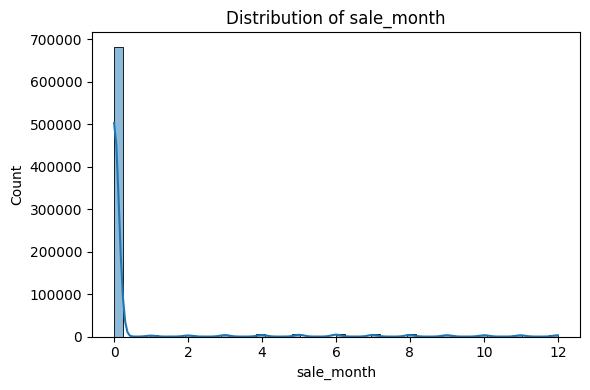

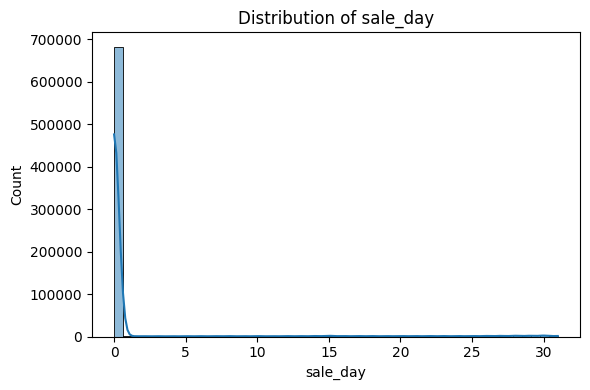

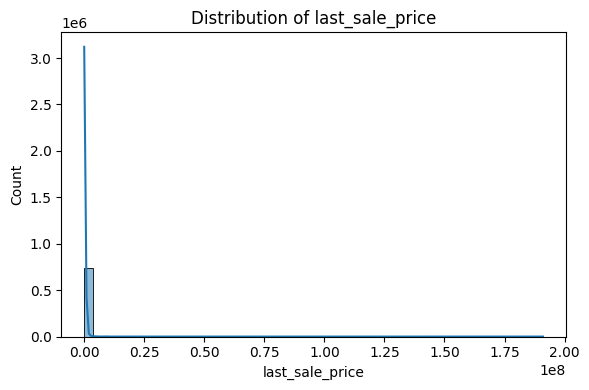

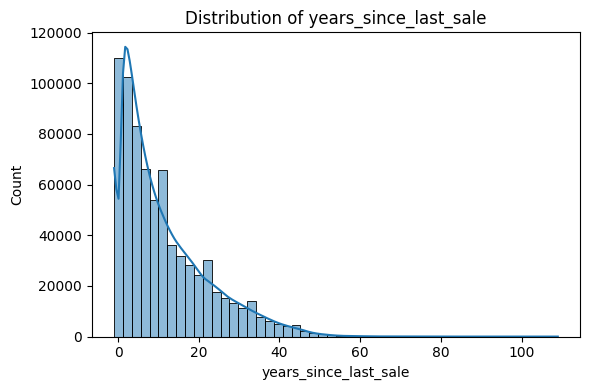

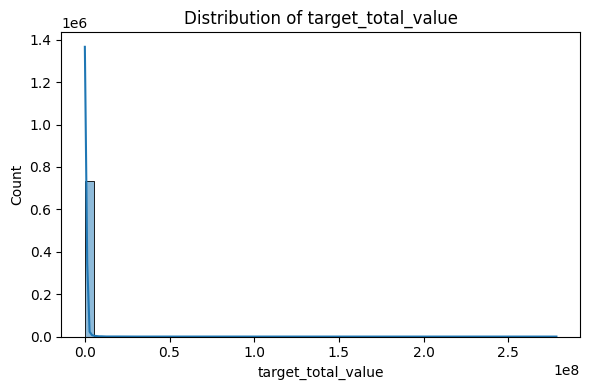

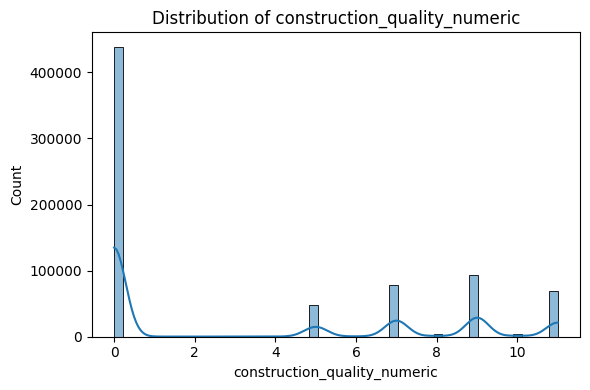

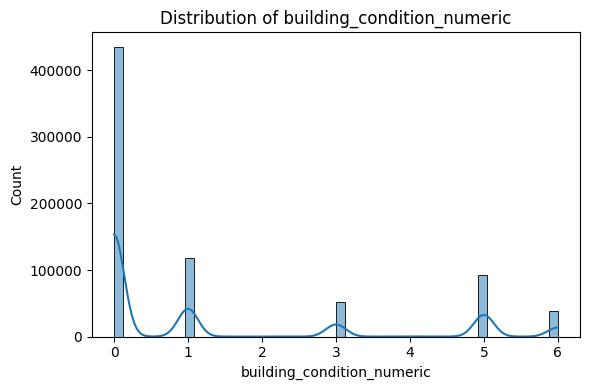

In [113]:
# Plot
for col in continuous_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(target_linear_reg_df[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [114]:
cor_mat= target_linear_reg_df[:].corr()
cor_with_tar=cor_mat.sort_values(['target_total_value'],ascending=False)

print("The most relevant features (numeric) for the target are :")
cor_with_tar.target_total_value.head

The most relevant features (numeric) for the target are :


<bound method NDFrame.head of target_total_value              1.000000
total_value                     0.984884
building_value                  0.943742
land_value                      0.735771
building_type_Healthcare        0.447225
last_sale_price                 0.289625
hvac_WARM AND COOL AIR ZONE     0.176481
hvac_HOT WATER                  0.138497
hvac_COMPLETE HVAC              0.135618
building_type_Office            0.122309
building_type_Industrial        0.115389
building_type_Hospitality       0.113384
building_type_Education         0.081628
hvac_PACKAGE UNIT               0.076453
hvac_HEAT PUMP                  0.064528
year                            0.053353
building_type_Other             0.052577
building_type_Civic             0.047957
building_type_Unknown           0.042398
hvac_UKNOWN                     0.042216
zip_code                        0.026649
building_type_Retail            0.018463
hvac_SPACE HEATER               0.014135
hvac_NONE                  

In [115]:
# Looking at the feature correlations, we can drop any of the columns with > 0.05 or < -0.05 correlation with the target.
low_corr_cols = cor_with_tar[abs(cor_with_tar['target_total_value']) < 0.20].index.tolist()
target_linear_reg_df = target_linear_reg_df.drop(columns=low_corr_cols)

<Axes: >

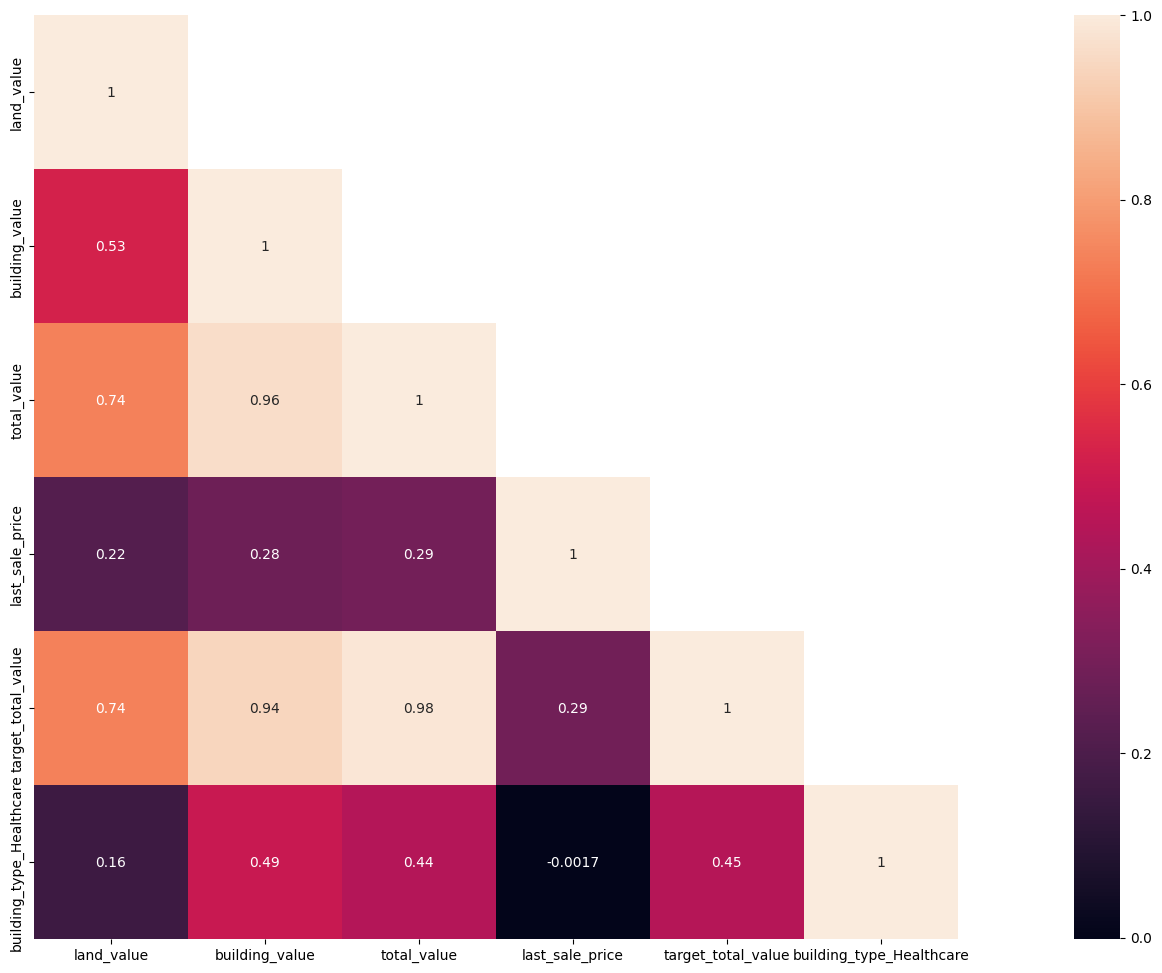

In [116]:
# using a corelation map to visualize features with high corelation.
cor_mat= target_linear_reg_df.corr()
mask = np.array(cor_mat)
mask[np.tril_indices_from(mask)] = False
fig=plt.gcf()
fig.set_size_inches(30,12)
sns.heatmap(data=cor_mat,mask=mask,square=True,annot=True,cbar=True)

In [124]:
skew_vals = target_linear_reg_df.skew().sort_values(ascending=False)
print(skew_vals)

building_type_Healthcare    175.202502
building_value               77.860732
total_value                  65.507224
target_total_value           64.322662
last_sale_price              57.734531
land_value                   37.384457
dtype: float64


In [125]:
y_skew = skew(target_linear_reg_df['target_total_value'])
print(f"Skewness of target_total_value: {y_skew:.2f}")

Skewness of target_total_value: 64.32


In [126]:
# Copy the DataFrame
target_reg_fixed = target_linear_reg_df.copy()

# Features to transform (based on your output)
skewed_cols = [
    'building_value', 'total_value', 'target_total_value',
    'last_sale_price', 'land_value'
]

# Log1p transform to reduce skew
for col in skewed_cols:
    if (target_reg_fixed[col] >= 0).all():
        target_reg_fixed[col] = np.log1p(target_reg_fixed[col])

In [127]:
skew_vals = target_reg_fixed.skew().sort_values(ascending=False)
print(skew_vals)

building_type_Healthcare    175.202502
last_sale_price              57.734531
land_value                   -3.806216
target_total_value           -3.809246
total_value                  -4.188738
building_value               -5.983436
dtype: float64


In [118]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [119]:
# Drop identifier column
X = target_linear_reg_df.drop(columns=['target_total_value'])

# Define the target
y = target_linear_reg_df['target_total_value']

In [120]:
from sklearn.preprocessing import StandardScaler

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Fit the model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Step 5: Predict and evaluate
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 212747903446.85
R² Score: 0.9636


In [105]:
print(y.describe())

count    7.367710e+05
mean     6.409354e+05
std      2.253852e+06
min      0.000000e+00
25%      2.825510e+05
50%      4.675280e+05
75%      7.184365e+05
max      2.785003e+08
Name: target_total_value, dtype: float64


In [93]:
coefficients = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefficients.head(10))  # Top 10 most impactful features

building_type_Healthcare       6.244747e+06
building_type_Hospitality      3.907096e+05
hvac_COMPLETE HVAC             1.410643e+05
building_type_Industrial       9.272923e+04
hvac_WARM AND COOL AIR ZONE    8.995865e+04
building_type_Office           5.192077e+04
hvac_HOT WATER                -1.291765e+04
building_type_Residential     -2.341744e+03
total_value                    6.643429e-01
land_value                     3.935349e-01
dtype: float64


In [69]:
sns.histplot(~np.isnan(target), kde=True)
plt.title('Target Distribution')
plt.show()

NameError: name 'target' is not defined

In [128]:
def quantile_plot(x, y, by=None, bins=10, by_bins=3, y_fn=np.mean):
    assert len(x) == len(y)

    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

        # Then define qp_data using x_clean and y_clean inside
    def qp_data(x, y):
        fac = np.searchsorted(np.quantile(x, q=[i / bins for i in range(1, bins)]), x)
        ufac = np.unique(fac)
        qx = np.array([np.mean(x[fac == f]) for f in ufac])
        qy = np.array([y_fn(y[fac == f]) for f in ufac])
        return qx, qy

    qx, qy = qp_data(x_clean, y_clean)

    if by is None:
        plt.plot(qx, qy, "-o")
    else:
        # If you use 'by', make sure to clean 'by' as well, aligned with mask
        assert len(x) == len(by)
        by_clean = by[mask]
        plt.plot(qx, qy, "-o", label="ALL", color="lightgrey")
        by_fac = np.searchsorted(np.quantile(by_clean, q=[i / by_bins for i in range(1, by_bins)]), by_clean)
        by_ufac = np.unique(by_fac)
        for i, f in enumerate(np.unique(by_ufac)):
            mask_by = by_fac == f
            nm = f"{i}) {min(by_clean[mask_by]):.2f} / {max(by_clean[mask_by]):.2f}"
            qx_group, qy_group = qp_data(x_clean[mask_by], y_clean[mask_by])
            plt.plot(qx_group, qy_group, "-o", label=nm)
        plt.legend()

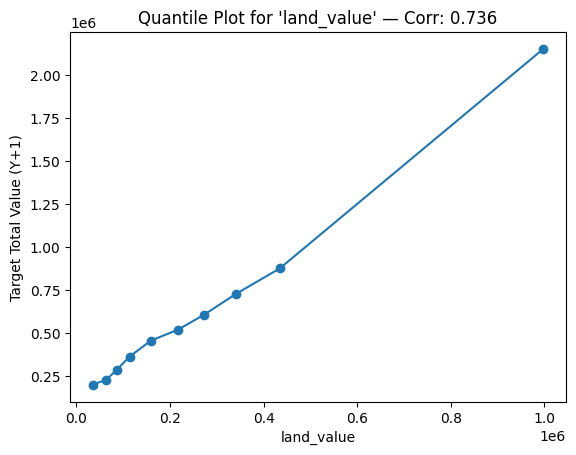

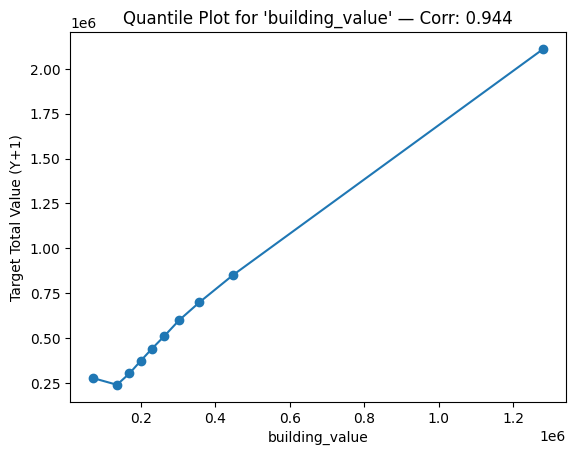

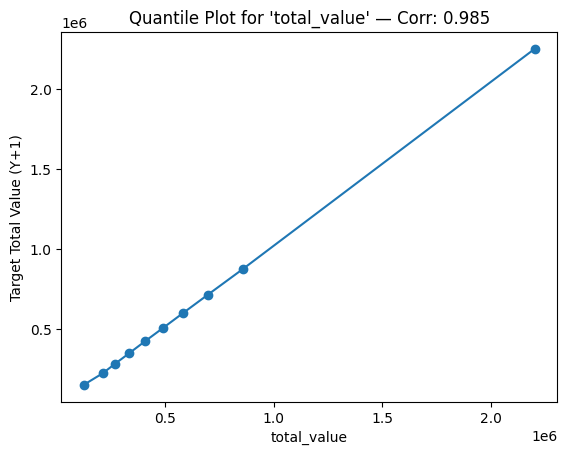

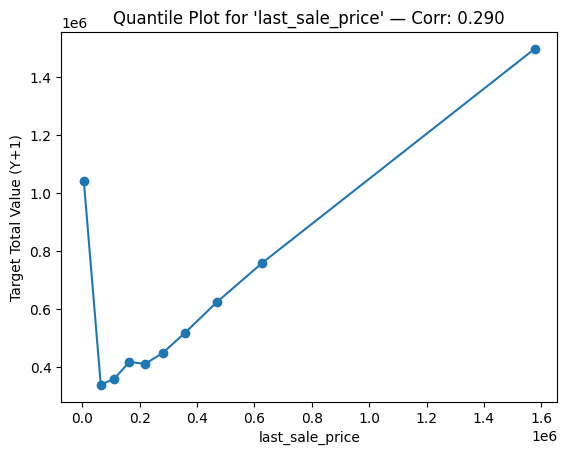

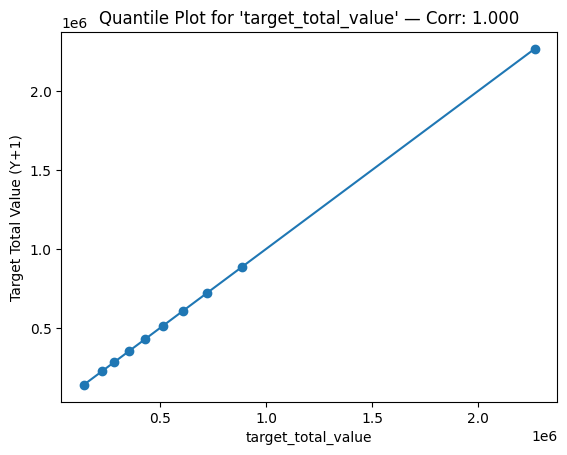

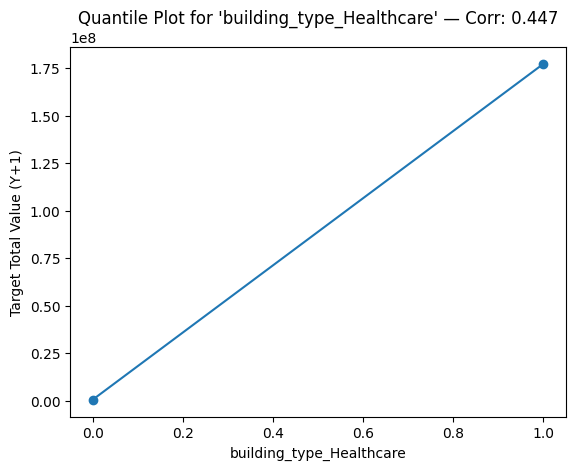

In [129]:
for col in target_linear_reg_df.columns:
    plt.figure()
    correlation = np.corrcoef(target_linear_reg_df[col], y)[0, 1]
    plt.title(f"Quantile Plot for '{col}' — Corr: {correlation:.3f}")
    quantile_plot(target_linear_reg_df[col], y)
    plt.ylabel("Target Total Value (Y+1)")
    plt.xlabel(col)
    plt.show()

In [ ]:
# Drop the original 'year_built' column
num_df.drop(columns=['year_built'], inplace=True)
num_df[num_df.notna().all(axis=1)].head()

In [ ]:
merged_df.head()

In [ ]:
merged_df.shape[0]

In [ ]:
missing_columns = merged_df.columns[merged_df.isnull().any()].values
print("Columns with missing values:")
for col in missing_columns:
    print(f"{col}: {merged_df[col].isnull().sum()} missing values or {merged_df[col].isnull().sum() / merged_df.shape[0]} percent missing values")

In [ ]:
merged_df = merged_df.drop(columns=['gross_building_area'], axis=1)
merged_df.head()

In [ ]:
# Select only categorical (object or category) columns
cat_cols = merged_df.select_dtypes(include=['object']).columns

# Print unique values in each
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(merged_df[col].unique())

In [ ]:
# Standardize categories
merged_df['construction_quality'] = merged_df['construction_quality'].replace(['.', '`', None], 'Unknown').fillna('Unknown')
merged_df['building_condition'] = merged_df['building_condition'].fillna('Unknown')
merged_df['hvac'] = merged_df['hvac'].replace(['ERROR', None], 'Unknown').fillna('Unknown')
merged_df['building_type'] = merged_df['building_type'].fillna('Unknown')

# One-hot encode categorical columns (drop_first avoids dummy trap)
merged_df = pd.get_dummies(merged_df, columns=[
    'construction_quality', 'building_condition', 'hvac', 'building_type'
], drop_first=True)

# Display the first few rows of the final DataFrame
merged_df.head()

In [ ]:
display(merged_df.columns.values) 

In [ ]:
merged_df['year_built_missing'] = merged_df['year_built'].isnull().astype(int)
merged_df['year_built'] = merged_df['year_built'].fillna(0)

In [ ]:
merged_df = merged_df[merged_df['sale_price'] > 0]
merged_df.head(10)

In [ ]:
merged_df = merged_df.drop(columns=['net_leasable_area'], axis=1)

In [ ]:
nan_columns = merged_df.isna().sum()
nan_columns = nan_columns[nan_columns > 0]

print("Columns with missing values:\n")
print(nan_columns)

In [ ]:
merged_df = merged_df.dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X = merged_df.drop(columns=['sale_price'])  # Features
y = merged_df['sale_price']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")